In [31]:
import pandas  as pd
import numpy as np

In [ ]:
batting_stats = pd.read_csv(r"E:\Data analysis projects\cricket_odi_analytics\data\batting_stats.csv", index_col="batter")
bowling_stats = pd.read_csv(r"E:\Data analysis projects\cricket_odi_analytics\data\bowling_stats.csv", index_col="bowler")

#### Rename Index to Player

In [4]:
batting_stats.index.name = "player"
bowling_stats.index.name = "player"

#### Merge Batting and Bowling Stats

In [5]:
all_rounders = pd.merge(
    batting_stats,
    bowling_stats,
    left_index=True,
    right_index=True,
    how="inner",
    suffixes=("_bat","_bowl")
)

#### Apply Minimum Criteria (To avoid part-time bowlers)

In [6]:
all_rounders = all_rounders[
    (all_rounders["runs"] >= 1500) &
    (all_rounders["wickets"] >= 50)
]

#### Create Impact Score

In [8]:
all_rounders["runs_score"] = all_rounders["runs"] / all_rounders["runs"].max()

all_rounders["bat_avg_score"] = all_rounders["average_bat"] / all_rounders["average_bat"].max()

all_rounders["wickets_score"] = all_rounders["wickets"] / all_rounders["wickets"].max()

all_rounders["econ_score"] = 1 - (all_rounders["economy"] / all_rounders["economy"].max())

In [11]:
all_rounders["impact_score"] = (
    ((all_rounders["runs_score"] * 0.30 +
    all_rounders["bat_avg_score"] * 0.20 +
    all_rounders["wickets_score"] * 0.30 +
    all_rounders["econ_score"] * 0.20)*100).round(2)
)

#### Top ODI All-Rounders

In [ ]:
top_allrounders = all_rounders.sort_values(
    "impact_score",
    ascending=False
).head(20)

print("\n" + "="*67)
print("TOP 20 Fielder (Imapact Score)")
print("="*67)
print(top_allrounders[["runs","average_bat","wickets","economy","impact_score"]])


TOP 20 Fielder (Imapact Score)
                 runs  average_bat  wickets  economy  impact_score
player                                                            
Shakib Al Hasan  6638        37.93      279     4.60         70.29
TM Dilshan       9212        40.23       97     4.90         58.95
Mohammad Hafeez  6351        33.96      142     4.17         54.60
Shahid Afridi    3913        23.29      259     4.67         53.78
SR Watson        5357        41.85      162     5.04         53.52
AD Mathews       5646        40.91      137     4.69         52.57
RA Jadeja        2880        32.36      244     4.92         51.25
Yuvraj Singh     6932        39.39      102     5.13         51.02
Shoaib Malik     5981        33.98      133     4.73         50.61
CH Gayle         6433        34.04      112     4.74         49.81
MJ Clarke        6988        43.40       56     4.95         48.28
EA Perry         3673        55.65       83     4.43         46.48
JH Kallis        4929        4

#### Visualization

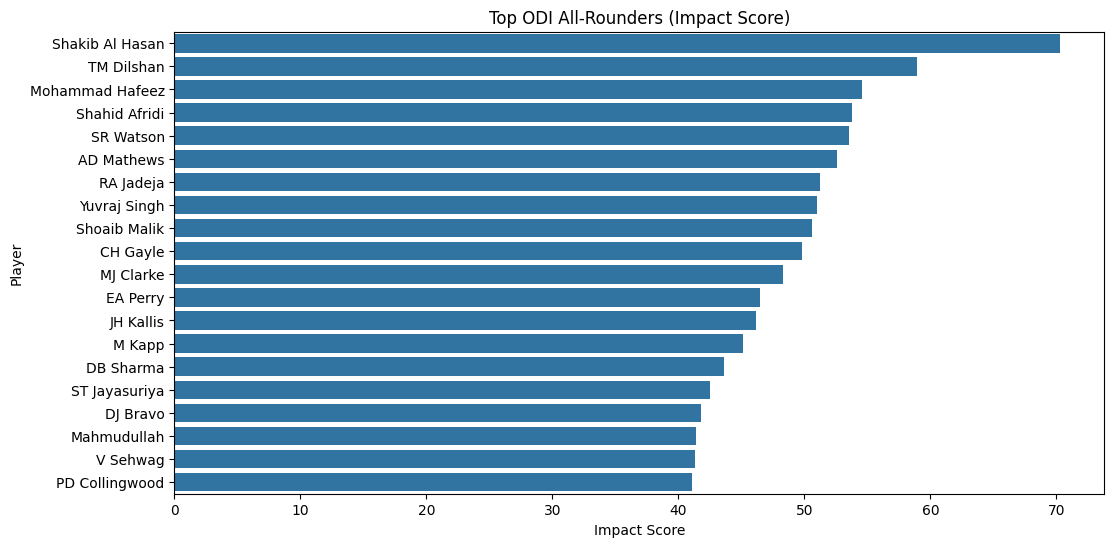

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_allrounders["impact_score"],
    y=top_allrounders.index
)

plt.title("Top ODI All-Rounders (Impact Score)")
plt.xlabel("Impact Score")
plt.ylabel("Player")

plt.show()

#### `advanced plot function`

In [32]:
def plot_allrounder_stats(batting_stats, bowling_stats, min_runs=1000, min_wickets=50):
    """
    Create comprehensive all-rounder visualizations
    """
    # Prepare data for all-rounders
    if 'batter' in batting_stats.columns:
        batting_for_merge = batting_stats.rename(columns={'batter': 'player'})
    else:
        batting_for_merge = batting_stats.reset_index().rename(columns={'index': 'player'})
    
    if 'bowler' in bowling_stats.columns:
        bowling_for_merge = bowling_stats.rename(columns={'bowler': 'player'})
    else:
        bowling_for_merge = bowling_stats.reset_index().rename(columns={'index': 'player'})
    
    # Merge batting and bowling stats
    allrounders = pd.merge(
        batting_for_merge,
        bowling_for_merge,
        on='player',
        how='inner',
        suffixes=('_bat', '_ball')
    )
    
    # Filter for genuine all-rounders
    allrounders = allrounders[
        (allrounders['runs'] > min_runs) & 
        (allrounders['wickets'] > min_wickets)
    ].copy()
    
    # Calculate all-rounder metrics
    allrounders['bat_impact'] = (allrounders['runs'] / allrounders['runs'].max() * 50)
    allrounders['ball_impact'] = (allrounders['wickets'] / allrounders['wickets'].max() * 50)
    allrounders['allrounder_score'] = allrounders['bat_impact'] + allrounders['ball_impact']
    
    top15_allrounders = allrounders.sort_values('allrounder_score', ascending=False).head(15)
    
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    
    # Plot 1: Top all-rounders by combined score
    sns.barplot(
        data=top15_allrounders,
        x='allrounder_score',
        y='player',
        ax=axes[0,0],
        palette='Spectral'
    )
    axes[0,0].set_title('Top 15 All-Rounders (Combined Score)', fontsize=14)
    axes[0,0].set_xlabel('All-Rounder Score')
    
    # Plot 2: Runs vs Wickets scatter
    scatter = axes[0,1].scatter(
        allrounders['runs'],
        allrounders['wickets'],
        s=allrounders['allrounder_score']*2,
        alpha=0.6,
        c=allrounders['allrounder_score'],
        cmap='viridis'
    )
    axes[0,1].set_title('Runs vs Wickets - All-Rounders', fontsize=14)
    axes[0,1].set_xlabel('Total Runs')
    axes[0,1].set_ylabel('Total Wickets')
    plt.colorbar(scatter, ax=axes[0,1], label='All-Rounder Score')
    
    # Add labels for top all-rounders
    for i, row in top15_allrounders.iterrows():
        axes[0,1].annotate(
            row['player'],
            (row['runs'], row['wickets']),
            fontsize=8
        )
    
    # Plot 3: Batting Average vs Bowling Average
    avg_bat_mean = allrounders['average_bat'].replace([np.inf, -np.inf], 0).mean()
    avg_ball_mean = allrounders['average_ball'].replace([np.inf, -np.inf], 0).mean()
    
    scatter2 = axes[1,0].scatter(
        allrounders['average_bat'].replace([np.inf, -np.inf], 0),
        allrounders['average_ball'].replace([np.inf, -np.inf], 0),
        s=allrounders['allrounder_score']*2,
        alpha=0.6,
        c=allrounders['allrounder_score'],
        cmap='plasma'
    )
    axes[1,0].axvline(avg_bat_mean, linestyle='--', color='gray', alpha=0.7)
    axes[1,0].axhline(avg_ball_mean, linestyle='--', color='gray', alpha=0.7)
    axes[1,0].set_title('Batting Average vs Bowling Average', fontsize=14)
    axes[1,0].set_xlabel('Batting Average')
    axes[1,0].set_ylabel('Bowling Average')
    
    # Quadrant labels
    axes[1,0].text(avg_bat_mean*1.2, avg_ball_mean*0.8, 'Batting All-Rounder', fontsize=10)
    axes[1,0].text(avg_bat_mean*0.8, avg_ball_mean*1.2, 'Bowling All-Rounder', fontsize=10)
    axes[1,0].text(avg_bat_mean*1.2, avg_ball_mean*1.2, 'Weak', fontsize=10)
    axes[1,0].text(avg_bat_mean*0.8, avg_ball_mean*0.8, 'Genuine All-Rounder', fontsize=10, fontweight='bold')
    
    # Plot 4: Strike Rate vs Economy (for all-rounders)
    scatter3 = axes[1,1].scatter(
        allrounders['strike_rate_bat'],
        allrounders['economy'],
        s=allrounders['allrounder_score']*2,
        alpha=0.6,
        c=allrounders['wickets'],
        cmap='coolwarm'
    )
    axes[1,1].set_title('Batting Strike Rate vs Bowling Economy', fontsize=14)
    axes[1,1].set_xlabel('Batting Strike Rate')
    axes[1,1].set_ylabel('Bowling Economy')
    plt.colorbar(scatter3, ax=axes[1,1], label='Wickets')
    
    plt.tight_layout()
    plt.suptitle('All-Rounder Statistics Analysis', fontsize=16, y=1.02)
    plt.show()

C:\Users\sk computers\AppData\Local\Temp\ipykernel_18428\4069210638.py:41: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


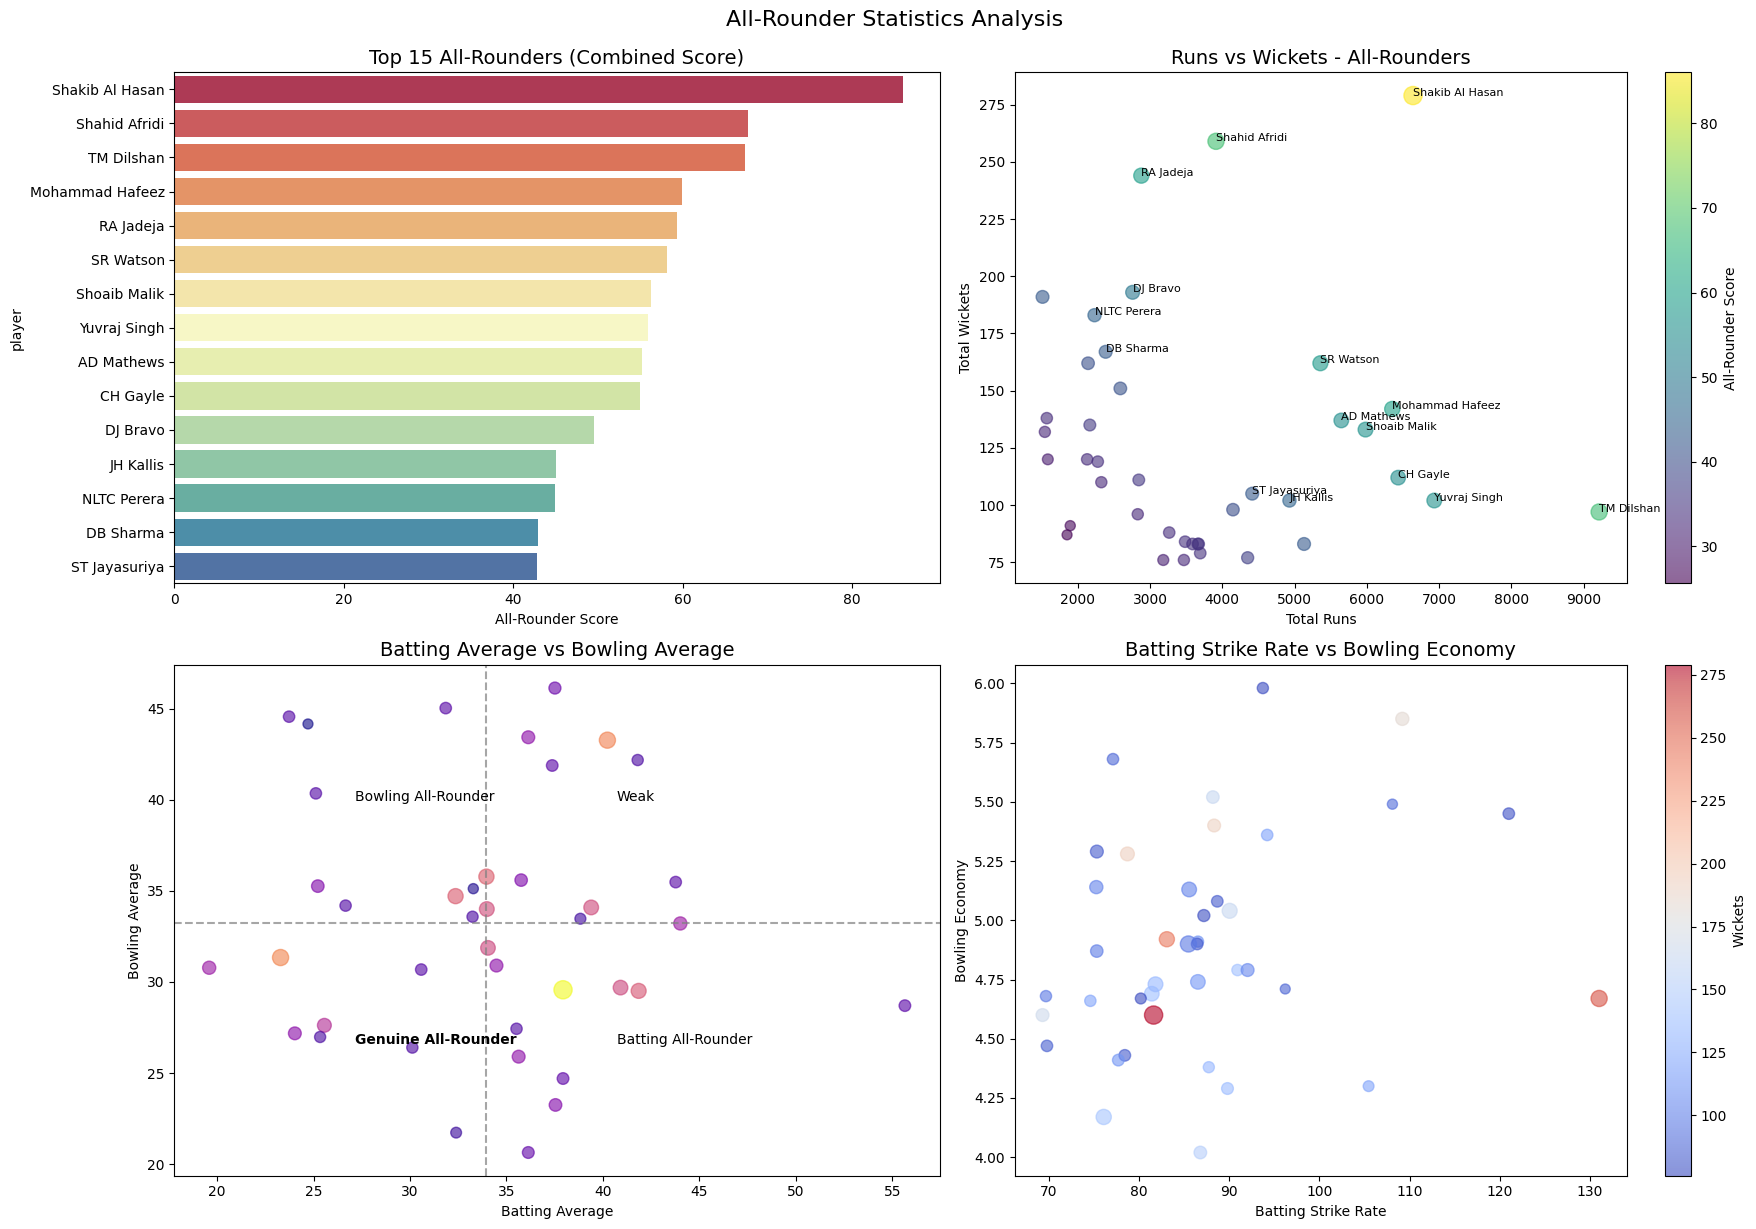

In [33]:
allrounders_df = plot_allrounder_stats(batting_stats, bowling_stats, min_runs=1500, min_wickets=75)

#### `Save dataset`

In [25]:
all_rounders.to_csv("../data/all_rounder_stats.csv", index=True)

In [27]:
df_all_rounder = pd.read_csv(r"E:\Data analysis projects\cricket_odi_analytics\data\all_rounder_stats.csv")

In [28]:
df_all_rounder.head()

,player,team_bat,matches_bat,innings_bat,dismisals,not_out,runs,balls_bat,fours,sixes,...,strike_rate_bowl,dot_pct,4w,5w,best_bowling,runs_score,bat_avg_score,wickets_score,econ_score,impact_score
0,A Flintoff,England,74,74,60,14,2168,2414,213,56,...,28.84,59.37,10,3,5/19,0.235345,0.649236,0.483871,0.302439,40.61
1,A Gardner,Australia,62,62,49,13,1587,1505,165,40,...,30.36,56.38,5,1,5/30,0.172275,0.582031,0.430108,0.300813,35.73
2,A Symonds,Australia,105,105,82,23,3589,4047,304,73,...,41.88,46.66,1,1,5/18,0.389601,0.786523,0.297491,0.173984,39.82
3,AC Jayangani,Sri Lanka,85,85,80,5,3151,4114,395,58,...,39.06,46.43,3,1,5/42,0.342054,0.707817,0.189964,0.138211,32.88
4,AC Kerr,New Zealand,71,72,60,12,2131,2856,208,4,...,35.30,51.16,8,2,7/34,0.231329,0.638275,0.430108,0.242276,37.45
